# Лабораторная №1 по NLP. Создание полносвязных нейронных сетей для решения задач **регрессии** и **классификации**

## Иморты

In [45]:
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch
import pandas as pd
import numpy as np
import seaborn as sns
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score, f1_score, accuracy_score, precision_score, recall_score, confusion_matrix, roc_auc_score, roc_curve, auc, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score

In [46]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [47]:
import torch
print(f"Версия Torch: {torch.__version__}")
print(f"CUDA доступна: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Имя карты: {torch.cuda.get_device_name(0)}")

Версия Torch: 2.8.0+cu128
CUDA доступна: True
Имя карты: NVIDIA GeForce RTX 2060


In [48]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## Задача регрессии

In [49]:
data_reg = pd.read_csv('mumbai_houses_task_filtred.csv')
data_reg

,price,area,latitude,longitude,bedrooms,bathrooms,balcony,status,neworold,parking,furnished_status,lift,type_of_building
0,22400000,629,19.032800,72.896357,2,2,0,0,1,0,0,0,0
1,35000000,974,19.032800,72.896357,3,2,0,0,1,0,0,0,0
2,31700000,968,19.085600,72.909277,3,3,0,0,1,0,0,0,0
3,18700000,629,19.155756,72.846862,2,2,2,1,1,2,0,2,0
4,13500000,1090,19.177555,72.849887,2,2,0,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6232,19500000,810,19.138320,72.810020,2,2,0,1,0,0,2,0,0
6233,22000000,1400,19.221920,72.854250,3,3,1,1,0,1,0,1,0
6234,20000000,750,19.144320,72.824111,2,2,0,1,0,0,0,0,0
6235,11000000,700,19.047201,72.872225,2,2,0,1,0,0,1,0,0


In [50]:
data_reg['price'].describe()

count    6.237000e+03
mean     2.686215e+07
std      2.792125e+07
min      1.500000e+06
25%      1.300000e+07
50%      1.900000e+07
75%      3.000000e+07
max      3.600000e+08
Name: price, dtype: float64

Датасет полностью предобработан, но в нем присутствуют идентичные друг другу признаки, поэтому они будут удалены из датасета.

In [51]:
mask_dup = data_reg.T.duplicated(keep='first')
drop_cols = data_reg.columns[mask_dup].tolist()
data_reg = data_reg.loc[:, ~mask_dup]

print("удалены:", drop_cols)
data_reg

удалены: ['parking', 'lift']


,price,area,latitude,longitude,bedrooms,bathrooms,balcony,status,neworold,furnished_status,type_of_building
0,22400000,629,19.032800,72.896357,2,2,0,0,1,0,0
1,35000000,974,19.032800,72.896357,3,2,0,0,1,0,0
2,31700000,968,19.085600,72.909277,3,3,0,0,1,0,0
3,18700000,629,19.155756,72.846862,2,2,2,1,1,0,0
4,13500000,1090,19.177555,72.849887,2,2,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6232,19500000,810,19.138320,72.810020,2,2,0,1,0,2,0
6233,22000000,1400,19.221920,72.854250,3,3,1,1,0,0,0
6234,20000000,750,19.144320,72.824111,2,2,0,1,0,0,0
6235,11000000,700,19.047201,72.872225,2,2,0,1,0,1,0


Также у целевого признака очень скошено распределение, поэтому применю логарифмирование

In [52]:
X_reg = data_reg.drop(columns=['price']).to_numpy()
y_reg = data_reg['price'].to_numpy()
y_reg = y_reg.reshape(-1, 1)
y_reg = np.log1p(y_reg)

In [53]:
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(X_reg, y_reg, test_size=0.05)
X_reg_train.shape, X_reg_test.shape, y_reg_train.shape, y_reg_test.shape

((5925, 10), (312, 10), (5925, 1), (312, 1))

In [54]:
scaler_X = StandardScaler()
X_reg_train = scaler_X.fit_transform(X_reg_train)
X_reg_test  = scaler_X.transform(X_reg_test)

In [55]:
train_reg_ds = TensorDataset(torch.from_numpy(X_reg_train).type(torch.float32), torch.from_numpy(y_reg_train).type(torch.float32))
train_reg_dl = DataLoader(train_reg_ds, batch_size=256, shuffle=True)
test_reg_ds = TensorDataset(torch.from_numpy(X_reg_test), torch.from_numpy(y_reg_test))
test_reg_dl = DataLoader(test_reg_ds, batch_size=256, shuffle=False)

### Создание модели

In [56]:
class MyRegressionModel(nn.Module): 
    def __init__(self, input_size: int): 
        super(MyRegressionModel, self).__init__() 
        self.first_reg_linear = nn.Linear(in_features=input_size, out_features=64) 
        self.first_reg_relu = nn.ReLU() 
        self.first_reg_dropout = nn.Dropout(p=0.2)
        
        self.second_reg_linear = nn.Linear(in_features=64, out_features=32) 
        self.second_reg_relu = nn.ReLU() 
        self.second_reg_dropout = nn.Dropout(p=0.3)
        
        self.third_reg_linear = nn.Linear(in_features=32, out_features=16) 
        self.third_reg_relu = nn.ReLU() 
        self.third_reg_dropout = nn.Dropout(p=0.2)
        
        self.fourth_reg_linear = nn.Linear(in_features=16, out_features=1)
    
    def forward(self, x): 
        y = self.first_reg_linear(x) 
        y = self.first_reg_relu(y) 
        y = self.first_reg_dropout(y)
        
        y = self.second_reg_linear(y) 
        y = self.second_reg_relu(y) 
        y = self.second_reg_dropout(y)
        
        y = self.third_reg_linear(y) 
        y = self.third_reg_relu(y) 
        y = self.third_reg_dropout(y)
        
        y = self.fourth_reg_linear(y)
        return y

In [57]:
model = MyRegressionModel(input_size=X_reg_train.shape[1]).to(device)
model

MyRegressionModel(
  (first_reg_linear): Linear(in_features=10, out_features=64, bias=True)
  (first_reg_relu): ReLU()
  (first_reg_dropout): Dropout(p=0.2, inplace=False)
  (second_reg_linear): Linear(in_features=64, out_features=32, bias=True)
  (second_reg_relu): ReLU()
  (second_reg_dropout): Dropout(p=0.3, inplace=False)
  (third_reg_linear): Linear(in_features=32, out_features=16, bias=True)
  (third_reg_relu): ReLU()
  (third_reg_dropout): Dropout(p=0.2, inplace=False)
  (fourth_reg_linear): Linear(in_features=16, out_features=1, bias=True)
)

In [58]:
loss = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0025)

In [59]:
epochs = 500
for epoch in range(epochs):
    for x_b, y_b in train_reg_dl:
        x_b, y_b = x_b.to(device), y_b.to(device)
        outputs = model(x_b)
        loss_value = loss(outputs, y_b)
        loss_value.backward()
        optimizer.step()
        optimizer.zero_grad()
    print(f'Эпоха {epoch + 1}, Значение функции потерь: {loss_value.item()}')

Эпоха 1, Значение функции потерь: 221.8756866455078
Эпоха 2, Значение функции потерь: 47.227996826171875
Эпоха 3, Значение функции потерь: 24.21759605407715
Эпоха 4, Значение функции потерь: 24.06571388244629
Эпоха 5, Значение функции потерь: 29.468843460083008
Эпоха 6, Значение функции потерь: 17.187408447265625
Эпоха 7, Значение функции потерь: 16.687519073486328
Эпоха 8, Значение функции потерь: 16.71184730529785
Эпоха 9, Значение функции потерь: 24.497529983520508
Эпоха 10, Значение функции потерь: 11.190644264221191
Эпоха 11, Значение функции потерь: 19.400562286376953
Эпоха 12, Значение функции потерь: 18.672245025634766
Эпоха 13, Значение функции потерь: 20.32865333557129
Эпоха 14, Значение функции потерь: 16.562618255615234
Эпоха 15, Значение функции потерь: 16.698522567749023
Эпоха 16, Значение функции потерь: 16.17731475830078
Эпоха 17, Значение функции потерь: 15.378069877624512
Эпоха 18, Значение функции потерь: 16.324134826660156
Эпоха 19, Значение функции потерь: 14.27717

In [60]:
model.eval()
y_pred = model(torch.from_numpy(X_reg_test).to(device).type(torch.float32)).cpu()
y_pred = y_pred.detach().numpy()
y_pred = np.expm1(y_pred)
y_true = np.expm1(y_reg_test)

In [61]:
def show_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    
    print(f"MAE   : {mae:.4f}")
    print(f"MSE   : {mse:.4f}")
    print(f"RMSE  : {rmse:.4f}")
    print(f"R2    : {r2:.4f}")
    print(f"MAPE% : {mape:.2f}%")

In [62]:
def plot_residuals(y_true, y_pred, title="График остатков"):
    residuals = y_true - y_pred
    plt.figure(figsize=(7,5))
    plt.scatter(y_pred, residuals, alpha=0.6)
    plt.axhline(0, color="red", linestyle="--")
    plt.xlabel("Предсказанные значения")
    plt.ylabel("Остатки (y_true - y_pred)")
    plt.title(title)
    plt.show()

In [63]:
def plot_residual_hist(y_true, y_pred, bins=30, title="Распределение остатков"):
    residuals = y_true - y_pred
    plt.figure(figsize=(7,5))
    plt.hist(residuals, bins=bins, alpha=0.7, edgecolor="black")
    plt.xlabel("Остатки")
    plt.ylabel("Количество")
    plt.title(title)
    plt.show()

MAE   : 7739821.0321
MSE   : 274728767418762.6250
RMSE  : 16574943.9643
R2    : 0.5666
MAPE% : 26.34%


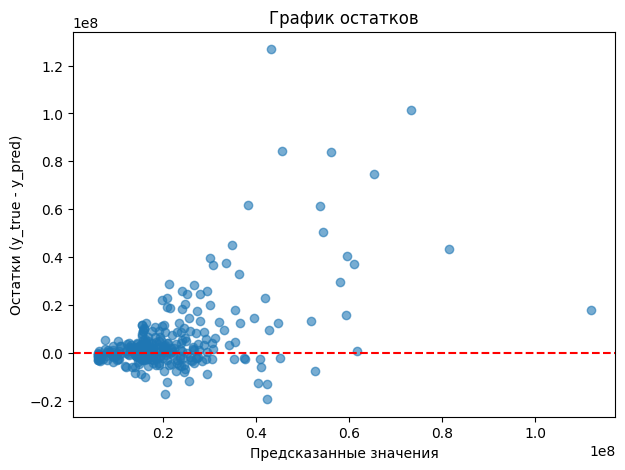

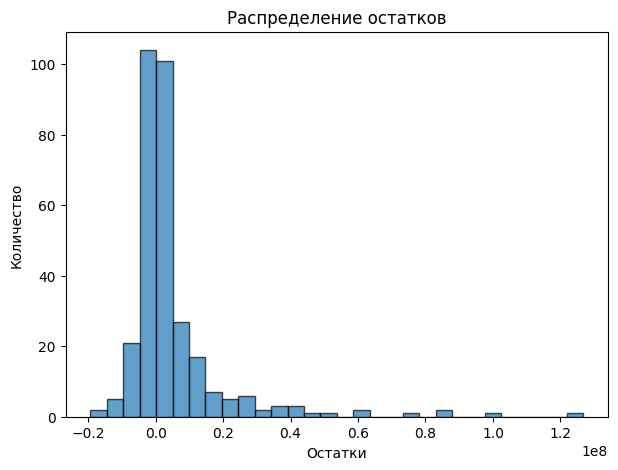

In [64]:
show_metrics(y_true, y_pred)
plot_residuals(y_true, y_pred)
plot_residual_hist(y_true, y_pred)

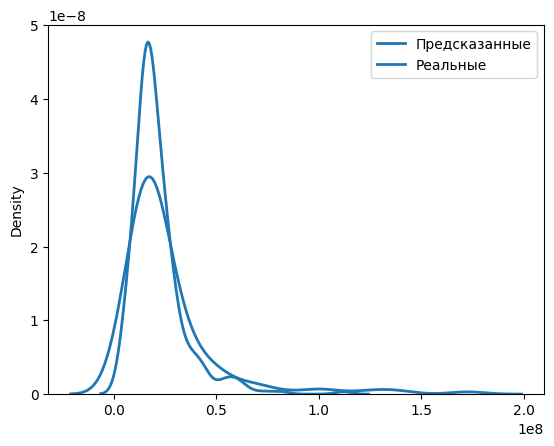

In [65]:
sns.kdeplot(y_pred, color='red', label='Предсказанные', linewidth=2)
sns.kdeplot(y_true, color='green', label='Реальные', linewidth=2)
plt.legend()
plt.show()

# Классификация

In [66]:
data_classifier = pd.read_csv('csgo_filtred.csv')

X_cl = data_classifier.drop(columns=['bomb_planted'], axis=1)
y_cl = data_classifier['bomb_planted']
data_classifier

,time_left,ct_score,t_score,map,bomb_planted,ct_health,t_health,ct_armor,t_armor,ct_money,...,ct_helmets,t_helmets,ct_defuse_kits,ct_players_alive,t_players_alive,health_lead,armor_lead,money_lead,helmets_lead,players_alive_lead
0,175.00,0,0,de_dust2,False,500,500,0,0,4000,...,0,0,0,5,5,2,2,2,2,2
1,156.03,0,0,de_dust2,False,500,500,400,300,600,...,0,0,1,5,5,2,0,1,2,2
2,96.03,0,0,de_dust2,False,391,400,294,200,750,...,0,0,1,4,4,1,0,0,2,2
3,76.03,0,0,de_dust2,False,391,400,294,200,750,...,0,0,1,4,4,1,0,0,2,2
4,174.97,1,0,de_dust2,False,500,500,192,0,18350,...,0,0,1,5,5,2,0,0,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116624,15.41,11,14,de_train,True,200,242,195,359,100,...,2,4,1,2,4,1,1,1,1,1
116625,174.93,11,15,de_train,False,500,500,95,175,11500,...,1,2,1,5,5,2,1,1,1,2
116626,114.93,11,15,de_train,False,500,500,495,475,1200,...,3,5,1,5,5,2,0,1,1,2
116627,94.93,11,15,de_train,False,500,500,495,475,1200,...,3,5,1,5,5,2,0,1,1,2


<Axes: ylabel='bomb_planted'>

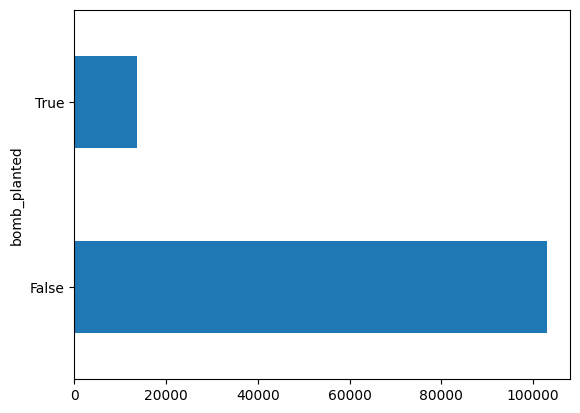

In [67]:
y_cl.value_counts().plot.barh()

In [68]:
y_cl.value_counts()

bomb_planted
False    102945
True      13684
Name: count, dtype: int64

In [69]:
X_cl['map'].value_counts()

map
de_inferno     22806
de_dust2       21040
de_nuke        17879
de_mirage      17641
de_overpass    13375
de_train       12800
de_vertigo     10733
unknown          211
de_cache         144
Name: count, dtype: int64

In [70]:
X_cl['map'] = X_cl['map'].str.strip().str.lower()
mapping = {
    'de_inferno': 1,
    'de_dust2': 2,
    'de_nuke': 3,
    'de_mirage': 4,
    'de_overpass': 5,
    'de_train': 6,
    'de_vertigo': 7,
    'unknown': 8,
    'de_cache': 9
}

X_cl['map'] = X_cl['map'].map(mapping)
X_cl['map'].value_counts()

map
1    22806
2    21040
3    17879
4    17641
5    13375
6    12800
7    10733
8      211
9      144
Name: count, dtype: int64

In [71]:
X_train_cl, X_test_cl, y_train_cl, y_test_cl = train_test_split(X_cl, y_cl, stratify=y_cl, train_size=0.8, test_size=0.2)
X_test_cl.shape, X_train_cl.shape

((23326, 20), (93303, 20))

In [72]:
scaler = StandardScaler().fit(X_train_cl)
Xtr0 = scaler.transform(X_train_cl).astype("float32")
Xte  = scaler.transform(X_test_cl ).astype("float32")

ytr0 = y_train_cl.to_numpy().astype(np.int64)
yte  = y_test_cl.to_numpy().astype(np.int64)

In [73]:
# sampler = SMOTEENN(
#     random_state=42, 
#     smote=SMOTE(random_state=42, sampling_strategy=0.5) # соотношение 0.5
# )
# Xtr, ytr = sampler.fit_resample(Xtr0, ytr0)

In [74]:
train_ds = TensorDataset(torch.from_numpy(Xtr0), torch.from_numpy(ytr0))
test_ds  = TensorDataset(torch.from_numpy(Xte),  torch.from_numpy(yte))

train_dl = DataLoader(train_ds, batch_size=128, shuffle=True,  pin_memory=True)
test_dl  = DataLoader(test_ds,  batch_size=256, shuffle=False, pin_memory=True)

In [75]:
class MyClassificationModel(nn.Module): 
    def __init__(self, input_size: int, n_classes: int = 2): 
        super(MyClassificationModel, self).__init__() 
        self.first_reg_linear = nn.Linear(input_size, 64) 
        self.first_reg_relu = nn.ReLU() 
        self.first_reg_dropout = nn.Dropout(p=0.2)

        self.second_reg_linear = nn.Linear(64, 32) 
        self.second_reg_relu = nn.ReLU() 
        self.second_reg_dropout = nn.Dropout(p=0.3)

        self.third_reg_linear = nn.Linear(32, 16) 
        self.third_reg_relu = nn.ReLU() 
        self.third_reg_dropout = nn.Dropout(p=0.2)

        self.fourth_reg_linear = nn.Linear(16, n_classes)
        self.softmax = nn.LogSoftmax(dim=1)
    
    def forward(self, x): 
        y = self.first_reg_linear(x);  y = self.first_reg_relu(y);  y = self.first_reg_dropout(y)
        y = self.second_reg_linear(y); y = self.second_reg_relu(y); y = self.second_reg_dropout(y)
        y = self.third_reg_linear(y);  y = self.third_reg_relu(y);  y = self.third_reg_dropout(y)
        y = self.fourth_reg_linear(y)
        y = self.softmax(y)
        return y

In [76]:
model = MyClassificationModel(input_size=Xtr0.shape[1], n_classes=2).to(device)
model

MyClassificationModel(
  (first_reg_linear): Linear(in_features=20, out_features=64, bias=True)
  (first_reg_relu): ReLU()
  (first_reg_dropout): Dropout(p=0.2, inplace=False)
  (second_reg_linear): Linear(in_features=64, out_features=32, bias=True)
  (second_reg_relu): ReLU()
  (second_reg_dropout): Dropout(p=0.3, inplace=False)
  (third_reg_linear): Linear(in_features=32, out_features=16, bias=True)
  (third_reg_relu): ReLU()
  (third_reg_dropout): Dropout(p=0.2, inplace=False)
  (fourth_reg_linear): Linear(in_features=16, out_features=2, bias=True)
  (softmax): LogSoftmax(dim=1)
)

In [77]:
weights = torch.tensor([1.0, 2.0]).to(device)
criterion = nn.NLLLoss(weight=weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

In [78]:
epochs = 100
for epoch in range(epochs):
    model.train()
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        probs = model(xb)
        loss = criterion(probs, yb)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    print(f'Эпоха {epoch + 1}, Значение функции потерь: {loss.item()}')

Эпоха 1, Значение функции потерь: 0.1046910211443901
Эпоха 2, Значение функции потерь: 0.16890010237693787
Эпоха 3, Значение функции потерь: 0.10135317593812943
Эпоха 4, Значение функции потерь: 0.08739899843931198
Эпоха 5, Значение функции потерь: 0.1323542296886444
Эпоха 6, Значение функции потерь: 0.08848001062870026
Эпоха 7, Значение функции потерь: 0.1560739278793335
Эпоха 8, Значение функции потерь: 0.11813812702894211
Эпоха 9, Значение функции потерь: 0.11744905263185501
Эпоха 10, Значение функции потерь: 0.15386313199996948
Эпоха 11, Значение функции потерь: 0.12073439359664917
Эпоха 12, Значение функции потерь: 0.09741243720054626
Эпоха 13, Значение функции потерь: 0.15343856811523438
Эпоха 14, Значение функции потерь: 0.1177743673324585
Эпоха 15, Значение функции потерь: 0.14591065049171448
Эпоха 16, Значение функции потерь: 0.11546344310045242
Эпоха 17, Значение функции потерь: 0.12333415448665619
Эпоха 18, Значение функции потерь: 0.17895866930484772
Эпоха 19, Значение функ

In [79]:
model.eval()
with torch.no_grad():
    X_test_t = torch.from_numpy(Xte).to(device)
    probs = model(X_test_t).detach().cpu().numpy()
    y_pred = probs.argmax(axis=1)
    y_proba_pos = probs[:, 1]
y_true = yte

In [80]:
print("Accuracy :", accuracy_score(y_true, y_pred))
print("F1:", f1_score(y_true, y_pred, average="binary"))
print("ROC-AUC :", roc_auc_score(y_true, y_proba_pos))
print("\nClassification report:\n", classification_report(y_true, y_pred, digits=3))
print("Confusion matrix:\n", confusion_matrix(y_true, y_pred))

Accuracy : 0.9391237245991597
F1: 0.782608695652174
ROC-AUC : 0.9817535969781993

Classification report:
               precision    recall  f1-score   support

           0      0.991     0.940     0.965     20589
           1      0.674     0.934     0.783      2737

    accuracy                          0.939     23326
   macro avg      0.832     0.937     0.874     23326
weighted avg      0.954     0.939     0.943     23326

Confusion matrix:
 [[19350  1239]
 [  181  2556]]
